### Instituto Superior Tecnologico Quito


![jupyter](img/itq.png)

**Nombre:** Maiccol Zurita

**Fecha:** 30/03/2026

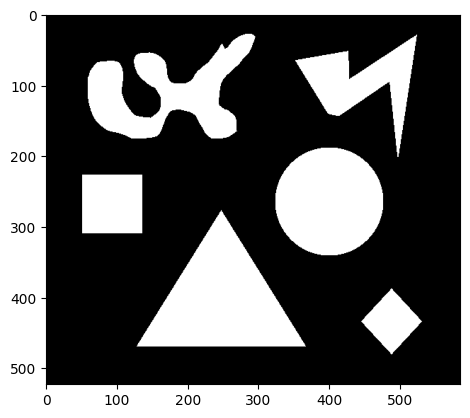

In [19]:
# En primer lugar, obtenemos la máscara de la imagen original mediante la umbralización con Otsu
import matplotlib.pyplot as plt
import cv2
import numpy as np
img = cv2.imread('images/figuras.png')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, mask = cv2.threshold(img_gray,0,1,cv2.THRESH_OTSU)

plt.imshow(mask, cmap='gray')
plt.show()

número de objetos:  6
posibles valores de intensidad:  [0 1 2 3 4 5 6]


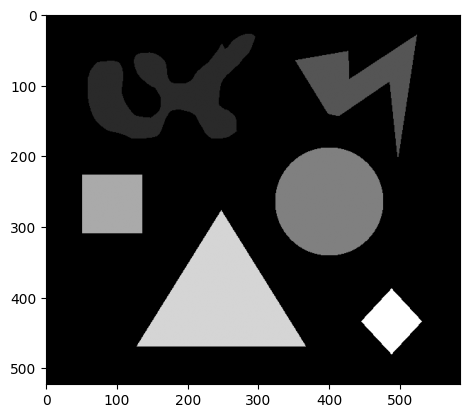

In [20]:
# Convertimos la imagen binaria en una imagen de etiquetas para tener acceso a cada objeto por separado
from skimage.measure import label

lab, num = label(mask, return_num=True)

# Importante:
# En 'num' devuelve 6 valores correspondientes a los 6 objetos que hay en la imagen.
# Sin embargo, 'lab' contiene hasta 7 valores diferentes, ya que también tiene en cuenta el fondo de la imagen.
print('número de objetos: ', num)
v,c = np.unique(lab, return_counts=True)
print('posibles valores de intensidad: ', v)

plt.imshow(lab, cmap='gray')
plt.show()

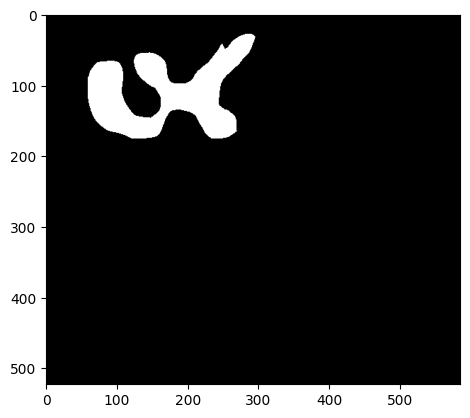

In [21]:
# Podemos acceder de manera independiente al objeto que nos interese a partir de su etiqueta correspondiente
objeto = lab == 1
objeto = objeto.astype('uint8')
plt.imshow(objeto, cmap='gray')
plt.show()

(28, 59, 176, 296)


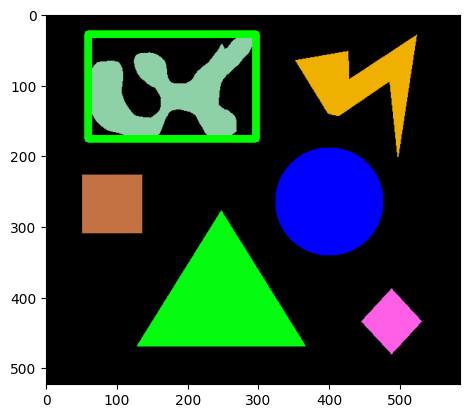

In [22]:
from skimage.measure import regionprops
# https://scikit-image.org/docs/dev/api/skimage.measure.html#skimage.measure.regionprops

# Después, podemos extraer la bounding box de dicho objeto
prop = regionprops(objeto)
bbox = prop[0].bbox
print(bbox)
start_point = (bbox[1], bbox[0])
end_point = (bbox[3], bbox[2])
window = cv2.rectangle(img.copy(), start_point, end_point, (0, 255, 0), 10)
                     
plt.imshow(window, cmap='gray')
plt.show()

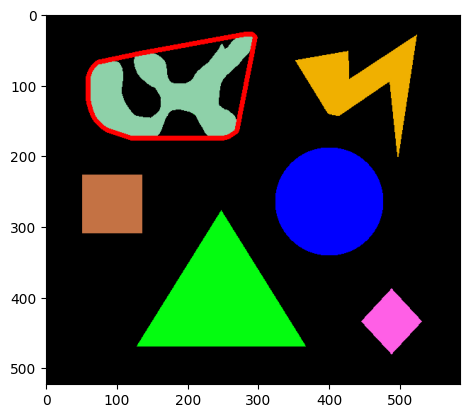

In [23]:
# Y la convex hull image
from skimage.morphology import convex_hull_image

convex_image = convex_hull_image(objeto)
convex_image = convex_image.astype('uint8')
# plt.imshow(convex_image, cmap='gray')
# plt.show()

conts,_ = cv2.findContours(convex_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE) # Encontramos los contornos en una máscara 
imagen = cv2.drawContours(img.copy(), conts, -1, (255,0,0), 5) # Dibujamos los contornos
                     
plt.imshow(imagen, cmap='gray')
plt.show()

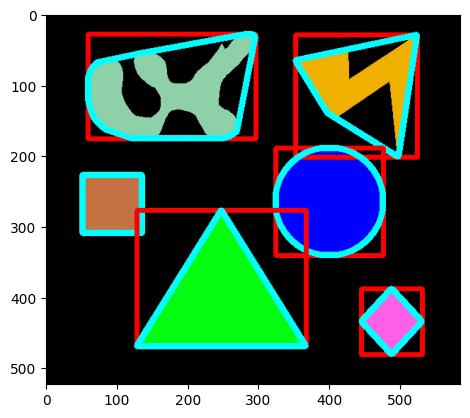

In [24]:
# Repetimos el proceso completo para todos los objetos de la imagen
imagen = img.copy()
for i in range(1, num+1): 
    objeto = lab == i
    objeto = objeto.astype('uint8')
    
    # bbox
    prop = regionprops(objeto)
    bbox = prop[0].bbox
    imagen = cv2.rectangle(imagen, (bbox[1], bbox[0]), (bbox[3], bbox[2]), (255, 0, 0), 5)
    
    # covex hull
    convex_image = convex_hull_image(objeto)
    convex_image = convex_image.astype('uint8')
    conts,_ = cv2.findContours(convex_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    imagen = cv2.drawContours(imagen, conts, -1, (0,255,255), 8)

plt.imshow(imagen, cmap='gray')
plt.show()

In [26]:
# Vamos a extraer diferentes descriptores geométricos que nos ayudarán a caracterizar los objetos.
# pip install tabulate
from tabulate import tabulate
import math

new_lab, new_num = label(mask, return_num=True)

# Extraemos las característicias geométricas
headers = ['','Raro', 'Rayo', 'Círculo', 'Cuadrado', 'Triángulo', 'Rombo']
A,BB,CA,E,ED,EX,MA,MiA,OR,P,S,CO,R = ['area'], ['bbox_area'], ['convex_area'], ['eccentricity'], ['equiv_diameter'], \
['extent'], ['major_axis'], ['minor_axis'], ['orientation'], ['perimeter'], ['solidity'], ['compactness'], ['rectangularity']

for i in range(1,new_num+1):
    objeto = new_lab == i
    prop = regionprops(objeto.astype(np.uint8))
    
    A.append(np.round(prop[0].area, 4))
    BB.append(np.round(prop[0].bbox_area, 4))
    CA.append(np.round(prop[0].convex_area, 4))
    E.append(np.round(prop[0].eccentricity, 4))
    ED.append(np.round(prop[0].equivalent_diameter, 4))
    EX.append(np.round(prop[0].extent, 4))
    MA.append(np.round(prop[0].major_axis_length, 4))
    MiA.append(np.round(prop[0].minor_axis_length, 4))
    OR.append(np.round(prop[0].orientation, 4))
    P.append(np.round(prop[0].perimeter, 4))
    S.append(np.round(prop[0].solidity, 4))
    CO.append(np.round(4*math.pi*prop[0].area/prop[0].perimeter**2, 4))
    R.append(np.round(prop[0].area/prop[0].bbox_area, 4))


my_data = [tuple(A), tuple(BB), tuple(CA), tuple(E), tuple(ED), tuple(EX), \
          tuple(MA), tuple(MiA), tuple(OR), tuple(P), tuple(S), tuple(CO), tuple(R)]

print(tabulate(my_data, headers=headers))

                      Raro        Rayo     Círculo    Cuadrado    Triángulo      Rombo
--------------  ----------  ----------  ----------  ----------  -----------  ---------
area            16198       10282       18344        7055        23119       4018
bbox_area       35076       29756       23104        7055        46127       7998
convex_area     27405       16959       18488        7055        23307       4102
eccentricity        0.8556      0.7941      0           0.2157       0.371      0.3866
equiv_diameter    143.61      114.418     152.828      94.7771     171.569     71.5254
extent              0.4618      0.3455      0.794       1            0.5012     0.5024
major_axis        268.45      186.995     152.828      98.1428     195.774     76.1969
minor_axis        138.975     113.644     152.828      95.8332     181.801     70.2735
orientation        -1.4236      1.5298     -0.7854      1.5708      -1.5708     0
perimeter        1029.77      736.02      503.245     332      

C:\Users\maicc\AppData\Local\Temp\ipykernel_24588\4149012655.py:18: FutureWarning: `RegionProperties.bbox_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_bbox` instead. 
  BB.append(np.round(prop[0].bbox_area, 4))
C:\Users\maicc\AppData\Local\Temp\ipykernel_24588\4149012655.py:19: FutureWarning: `RegionProperties.convex_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_convex` instead. 
  CA.append(np.round(prop[0].convex_area, 4))
C:\Users\maicc\AppData\Local\Temp\ipykernel_24588\4149012655.py:21: FutureWarning: `RegionProperties.equivalent_diameter` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.equivalent_diameter_area` instead. 
  ED.append(np.round(prop[0].equivalent_diameter, 4))
C:\Users\maicc\AppData\Local\Temp\ipykernel_24588\4149012655.py:23: FutureWarning: `RegionProperties.major_axis_length` is deprecated sta

**Github:** https://github.com/Maick721/MAQUINAS-E-LEARNING-2-.git

### Instituto Superior Tecnologico Quito

![jupyter](img/itq.png)

**Nombre:** Maiccol Zurita

**Fecha:** 30/03/2026

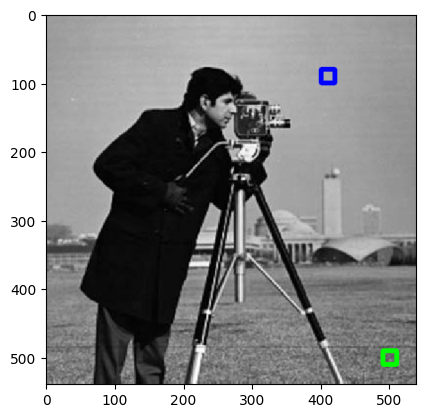

In [1]:
# En primer lugar, obtenemos la máscara de la imagen original mediante la umbralización con Otsu
import matplotlib.pyplot as plt
import cv2
import numpy as np
img = cv2.imread('images/photographer.png')

window = cv2.rectangle(img.copy(), (400,80), (420,100), (0, 0, 255), 5)
window = cv2.rectangle(window, (490,490), (510,510), (0, 255, 0), 5)
plt.imshow(window, cmap='gray')
plt.show()

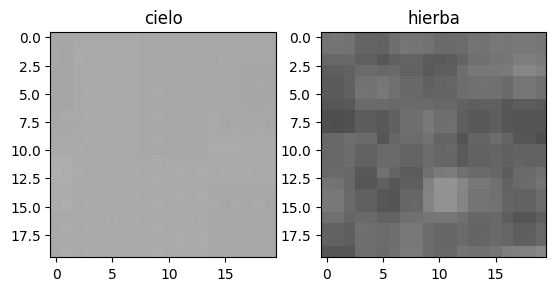

In [2]:
# Seleccionamos una región del cielo y una de la hierba
cielo = img[80:100, 400:420]
hierba = img[490:510, 490:510]

fig, ax = plt.subplots(1,2)
ax[0].imshow(cielo, cmap='gray')
ax[0].set_title('cielo')
ax[1].imshow(hierba, cmap='gray')
ax[1].set_title('hierba')
plt.show()

### MATRIZ DE COOCURRENCIA

In [12]:
import cv2
import numpy as np
from tabulate import tabulate
from skimage.feature import graycomatrix, graycoprops

headers = ['', 'cielo', 'hierba']
CN, DIS, H, ASM, E, COR = ['contraste'], ['disimilitud'], ['homogeneidad'], ['ASM'], ['Energía'], ['Correlación']

patches = [cielo, hierba]

for i in range(len(patches)):
    image = cv2.cvtColor(patches[i], cv2.COLOR_BGR2GRAY)
    GLCM = graycomatrix(image, distances=[5], angles=[0], levels=256, symmetric=True, normed=True)
    CN.append(graycoprops(GLCM, 'contrast')[0,0])
    DIS.append(graycoprops(GLCM, 'dissimilarity')[0,0])
    H.append(graycoprops(GLCM, 'homogeneity')[0,0])
    ASM.append(graycoprops(GLCM, 'ASM')[0,0])
    E.append(graycoprops(GLCM, 'energy')[0,0])
    COR.append(graycoprops(GLCM, 'correlation')[0,0])

my_data = [tuple(CN), tuple(DIS), tuple(H), tuple(ASM), tuple(E), tuple(COR)]
print(tabulate(my_data, headers=headers))

                 cielo        hierba
------------  --------  ------------
contraste     3.68      333.393
disimilitud   1.4        13.8533
homogeneidad  0.512471    0.0921279
ASM           0.142717    0.00510556
Energía       0.377779    0.0714532
Correlación   0.190521   -0.0705127


### Scale-Invariant Feature Transform

(1672, 128)


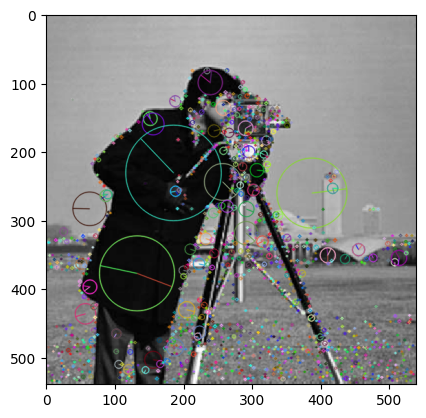

In [13]:
# SIFT algorithm
img = cv2.imread('images/photographer.png')

# Definición del algoritmo
sift = cv2.SIFT_create()

# Identificamos los puntos de interés
kp = sift.detect(img, None)

# Extraemos el descriptor para obtener el fingreprint
kp, des = sift.compute(img, kp)
print(np.shape(des))
# print(des) # Matriz donde las filas son los keypoints y las columnas las características de dichos puntos clave

# Visualizamos los puntos de interés
img=cv2.drawKeypoints(img, kp, img, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img)
plt.show()

### Histogram of Oriented Gradients 

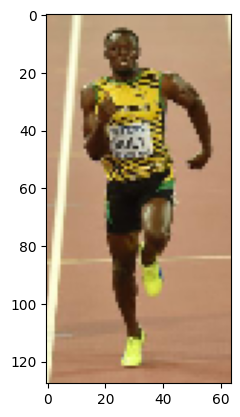

In [14]:
# HISTOGRAM OF ORIENTED GRADIENTS

# En primer lugar, obtenemos la máscara de la imagen original mediante la umbralización con Otsu
from skimage import io
img = io.imread('images/pedestrian.jpg')
img = np.float32(img/255)
crop = img[75:550,475:700]
crop = cv2.resize(crop, (64, 128))

plt.imshow(crop, cmap='gray')
plt.show()

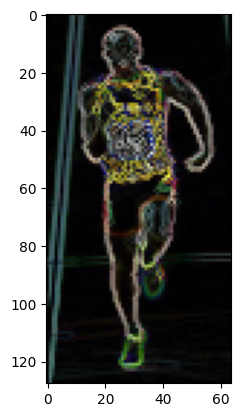

In [15]:
# Calculamos el gradiente con el kernel de Sobel
crop = np.float32(crop)
gx = cv2.Sobel(crop, cv2.CV_32F, 1, 0, ksize=1)
gy = cv2.Sobel(crop, cv2.CV_32F, 0, 1, ksize=1)

# Calculamos la magnitud y la dirección del gradiente
mag, angle = cv2.cartToPolar(gx, gy, angleInDegrees=True)

# Visualizamos la imagen obtenida en la magnitud del gradiente
mag = mag/np.max(mag)
plt.imshow(mag, cmap='gray')
plt.show()

In [19]:
from skimage.feature import hog
from skimage.color import rgb2gray

# Convertir a escala de grises
crop_gray = rgb2gray(crop)

# Calcular HOG
H = hog(crop_gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        transform_sqrt=True,
        block_norm="L1")

print(np.shape(H))

(3780,)


### Local Binary Patterns

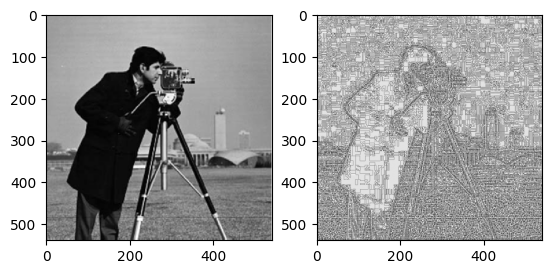

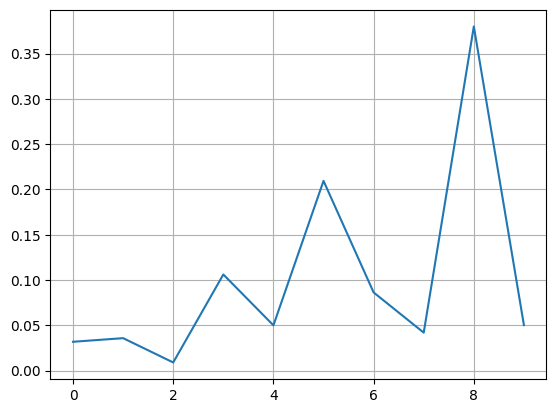

In [20]:
# LOCAL BINARY PATTERNS (LBP)
from skimage.feature import local_binary_pattern
img = cv2.imread('images/photographer.png')

# Definimos los parámetros iniciales
R = 1 # Radio
P = 8*R # Número de píxeles vecinos
epsilon = 1e-7 # Para normalizar el histograma

# Extraemos la imagen LBP
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
lbp_image = local_binary_pattern(img_gray, P, R, method='uniform')
a,b = np.unique(lbp_image, return_counts=True)

# Calculamos el histograma
lbp_image = np.uint8(lbp_image)
hist = cv2.calcHist([lbp_image.ravel()], [0], None, [P+2], [0, P+2])

# Normalizamos el histograma
hist = hist.astype("float")
hist /= (hist.sum() + epsilon)

# Los P+2=10 bins del histograma serán los 10 atributos que nos permitirán caracterizar una imagen

# Visualizamos la imagen LBP
figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray')
ax[1].imshow(lbp_image, cmap='gray')
plt.show()

# Visualizamos el histograma
plt.plot(hist)
plt.grid(True)
plt.show()

**Github:** https://github.com/Maick721/MAQUINAS-E-LEARNING-2-.git

### Instituto Superior Tecnologico Quito

![jupyter](img/itq.png)

**Nombre:** Maiccol Zurita

**Fecha:** 30/03/2026

### SEGMENTACIÓN MEDIANTE THRESHOLDING

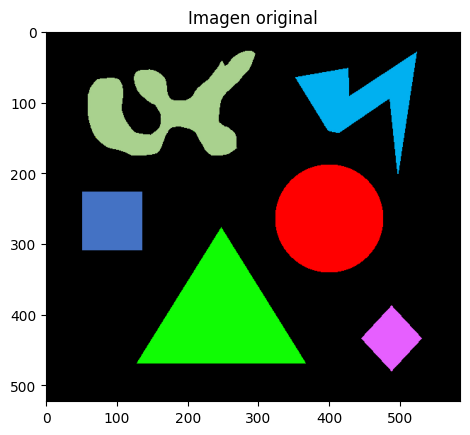

In [1]:
import matplotlib.pyplot as plt
import cv2

# Read an image
img = cv2.imread('images/figuras.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb, cmap='gray')
plt.title('Imagen original')
plt.show()

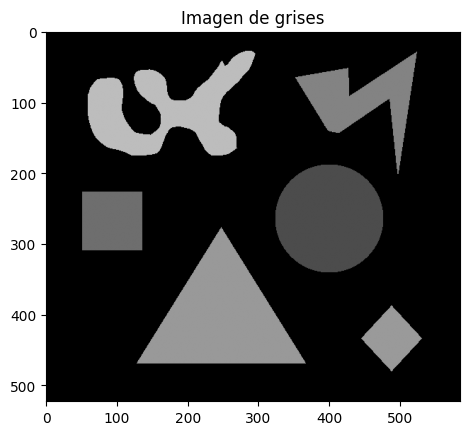

In [2]:
# Convertimos la imagen a escala de grises
import numpy as np
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#gray_img = cv2.imread('figuras.png', 0) # Una forma de leer la imagen directamente en escala de grises

plt.imshow(gray_img, cmap='gray')
plt.title('Imagen de grises')
plt.show()

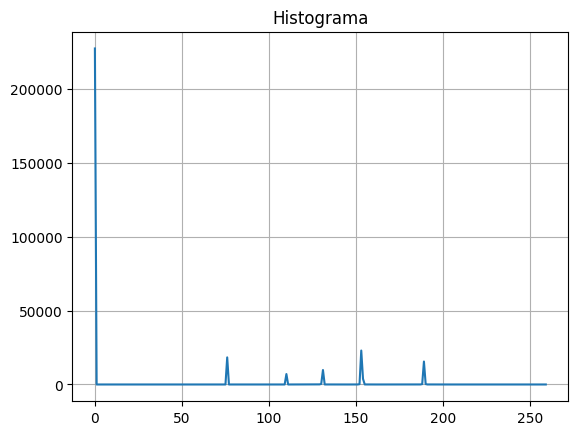

In [3]:
# Calculamos el histograma
hist = cv2.calcHist([gray_img], [0], None, [260], [0, 260]) # [0] son los canales, None la máscara

plt.plot(hist)
plt.grid()
plt.title('Histograma')
plt.show()

# Otra forma de mostrar el histograma (solo visualización)
# plt.hist(gray_img.ravel(), bins=50)
# plt.grid(True)
# plt.show()

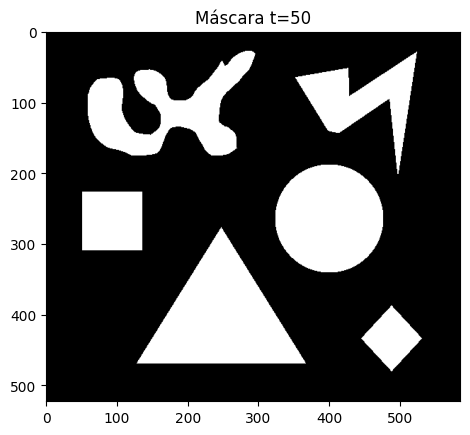

[  0 255]


In [4]:
# Fijamos el umbral en base al histograma anterior
t = 50

# Extreaemos la máscara binaria
maxim = 255
_, mask = cv2.threshold(gray_img, t, maxim, cv2.THRESH_BINARY)

# Otra formas de extraer la máscara 
# mask = gray_img.copy()
# mask = mask>t

# Visualizamos para corroborar
plt.imshow(mask, cmap='gray')
plt.title('Máscara t=' + str(t))
plt.show()

print(np.unique(mask)) # Atent@s a los formatos (bool, uint8, etc.)

[0 1]


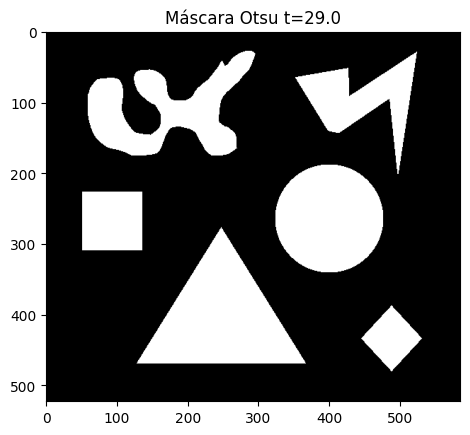

In [5]:
# Fijamos el umbral con el método de OTSU
t, mask = cv2.threshold(gray_img,0,1,cv2.THRESH_OTSU) # 0 es por defecto y 1 es el valor máximo de la máscara
print(np.unique(mask))

# Visualizamos para corroborar que se obtiene el mismo resultado
plt.imshow(mask, cmap='gray')
plt.title('Máscara Otsu t=' + str(t))
plt.show()

### SEGMENTACIÓN MEDIANTE CONVERSIONES DE COLOR

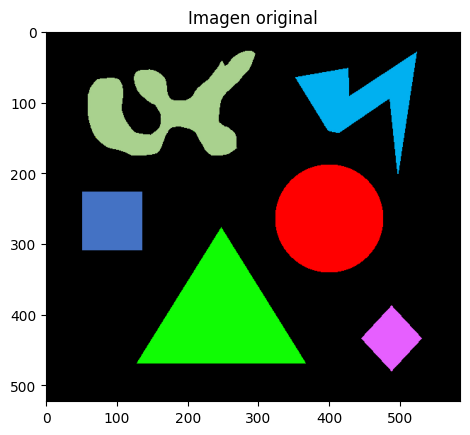

In [6]:
# Imaginamos que queremos segmentar únicamente el círculo
img = cv2.imread('images/figuras.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb, cmap='gray')
plt.title('Imagen original')
plt.show()

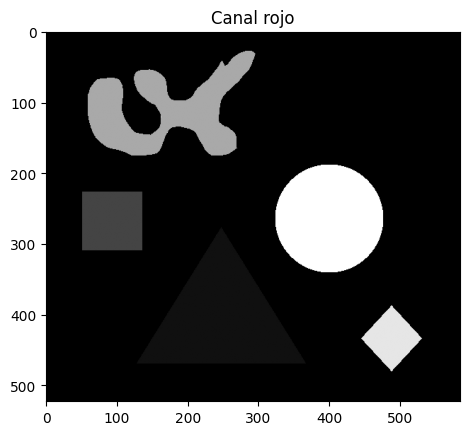

In [7]:
# Obtenemos el canal rojo
R = img[:,:,2]

plt.imshow(R, cmap='gray')
plt.title('Canal rojo')
plt.show()

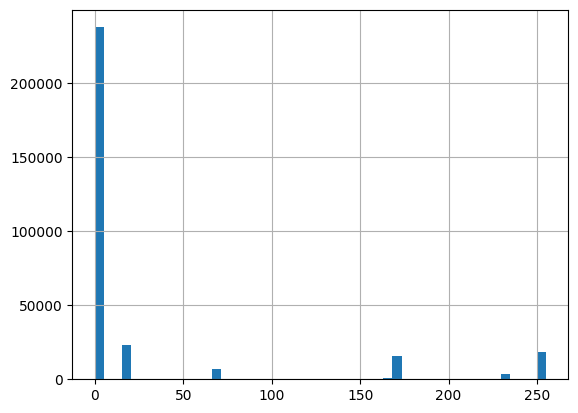

255


In [8]:
# Observamos el histograma
plt.hist(R.ravel(), bins=50)
plt.grid(True)
plt.show()
print(np.max(R))

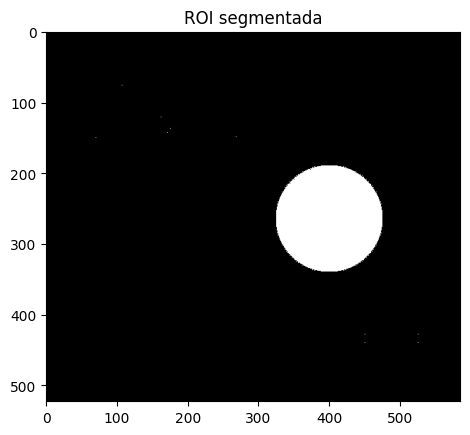

In [9]:
# Fijamos el umbral y extraemos la máscara
t=np.max(R)
mask = R.copy()
mask[mask<t] = 0

plt.imshow(mask, cmap='gray')
plt.title('ROI segmentada')
plt.show()

C:\Users\maicc\AppData\Local\Temp\ipykernel_9564\3238359124.py:11: RuntimeWarning: invalid value encountered in cast
  CMYK = (np.dstack((C,M,Y,K))*255).astype('uint8')


Object `?` not found.


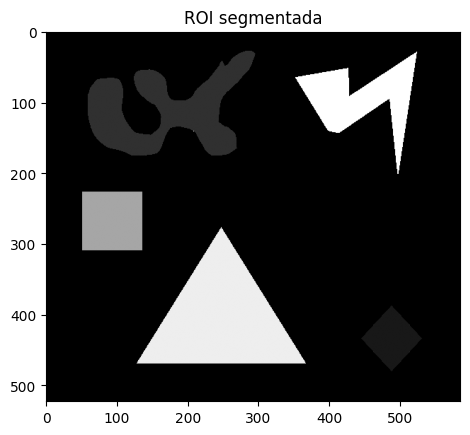

In [19]:
# Ejercicio individual
# Obtener una máscara con la imagen del rayo azul mediante segmentación por espacio de color

# Función para extraer los colores secundarios
def convert_to_CMYK(rgb_p):
    with np.errstate(invalid='ignore', divide='ignore'):
        K = 1 - np.max(rgb_p, axis=2)
        C = (1-rgb_p[:,:,0] - K)/(1-K)
        M = (1-rgb_p[:,:,1] - K)/(1-K)
        Y = (1-rgb_p[:,:,2] - K)/(1-K)
    CMYK = (np.dstack((C,M,Y,K))*255).astype('uint8')
    return CMYK

# Leer la imagen 
img = cv2.imread('images/figuras.png')
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
rgb_p = rgb.astype('uint8')/255

# Extraer los colores secundarios
CMYK = convert_to_CMYK(rgb_p)

# Extraer los canales por separado
C, M, Y, K = cv2.split(CMYK)

C = C.astype('uint8')

# Calcular la máscara de la figura del rayo
???

# Visualizar la máscara
plt.imshow(C, cmap='gray')
plt.title('ROI segmentada')
plt.show()

### SEGMENTACIÓN SEMÁNTICA CON DETECCIÓN DE BORDES

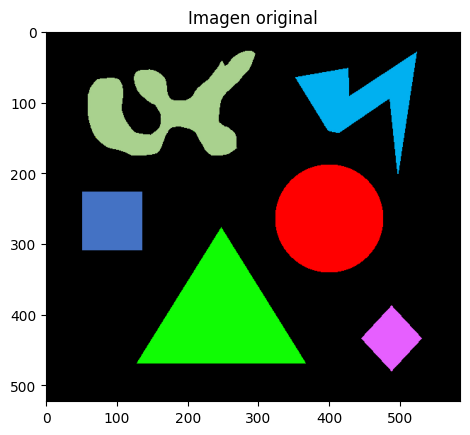

In [12]:
# SEGMENTACIÓN SEMÁNTICA CON DETECCIÓN DE BORDES
img = cv2.imread('images/figuras.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title('Imagen original')
plt.show()

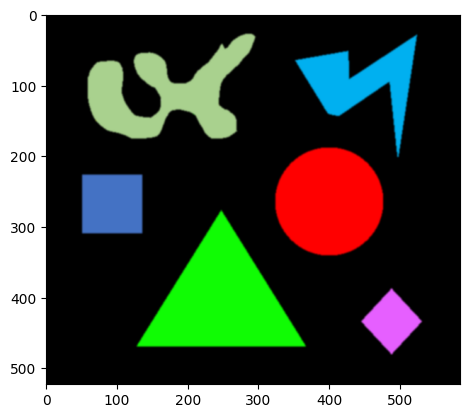

In [13]:
# Aplicamos un filtro gaussiano para emborronar las altas frecuencias
img_gaus = cv2.GaussianBlur(img_rgb, (5,5), 0) # (5x5) es el tamaño del filtro y 0 es la desviación estándar
plt.imshow(img_gaus, cmap='gray')
plt.show()

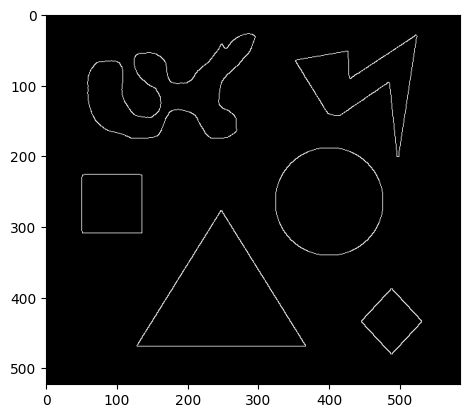

In [14]:
# Detección de bordes de Canny
canny = cv2.Canny(img_gaus, 255/3, 255) # minValue and maxValue. Canny recomienda que minValue sea 3 veces mayor que maxValue
kernel = np.ones((2,2), 'uint8')
#canny = cv2.dilate(canny, kernel, iterations=2)
#canny = cv2.erode(canny, kernel, iterations=2)

plt.imshow(canny, cmap='gray')
plt.show()

C:\Users\maicc\AppData\Local\Temp\ipykernel_9564\2220132281.py:2: DeprecationWarning: Please import `binary_fill_holes` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.morphology import binary_fill_holes as bfh


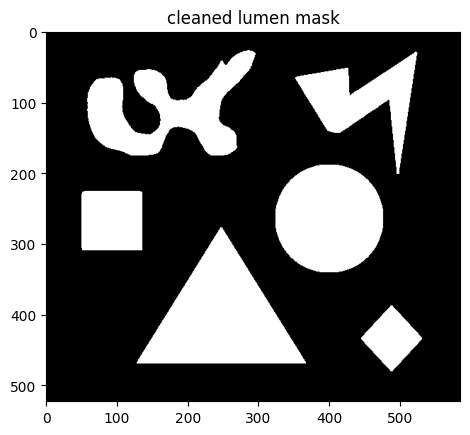

In [15]:
# Rellenar objetos (solo rellena si no están en contacto con el límite de la imagen)
bordes = canny.copy()
filled_bordes = bfh(bordes)

plt.imshow(filled_bordes.astype('uint8'), cmap='gray')
plt.title('cleaned lumen mask')
plt.show()

### SEGMENTACIÓN POR CRECIMIENTO DE REGIONES (region growing)

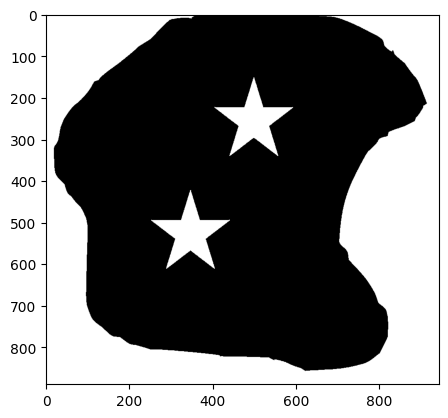

In [16]:
# Cargar imagen
from skimage import io
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('images/estrellas.png', 0)

plt.imshow(img, cmap='gray')
plt.show()

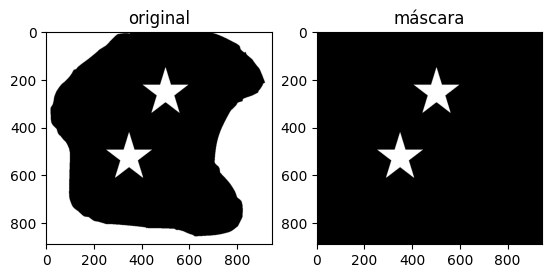

In [17]:
# Crear una copia de la imagen
mask = img.copy()

# Definir una imagen negra de referencia
h, w = img.shape
ref = np.zeros((h+2, w+2), np.uint8)

# Fijar la semilla. En este caso en la esquina superior izquierda (posición 0,0) para rellenar a partir de ahí
cv2.floodFill(mask, ref, (0,0), 0); # Como nos interesa rellenar de negro, utilizamos el 0 en la última posición

fig, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(mask, cmap='gray'), ax[1].set_title('máscara')
plt.show()

**Github:** https://github.com/Maick721/MAQUINAS-E-LEARNING-2-.git

### Instituto Superior Tecnologico Quito

![jupyter](img/itq.png)

**Nombre:** Maiccol Zurita

**Fecha:** 30/03/2026

Image dimensions:  (256, 256, 3)


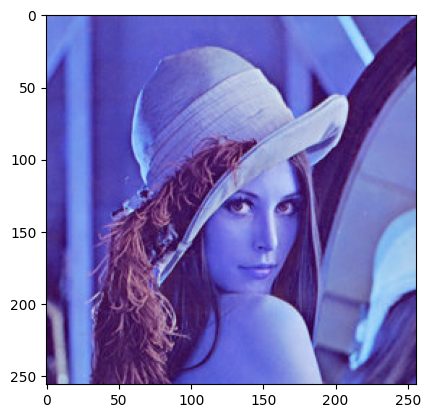

In [17]:
# READ AN IMAGE
# pip install opencv-python
import matplotlib.pyplot as plt
import cv2
import numpy as np

img = cv2.imread('images/Lena_RGB.png')
print('Image dimensions: ', np.shape(img))

plt.imshow(img, cmap='gray')
plt.show()

In [18]:
import cv2


R = img[:, :, 2]   # Canal Rojo
G = img[:, :, 1]   # Canal Verde
B = img[:, :, 0]   # Canal Azul

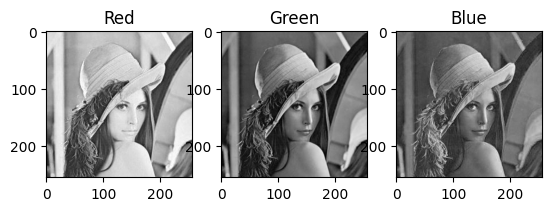

In [19]:
# Visualizar los canales en un subplot
fig, ax = plt.subplots(1,3)
ax[0].imshow(R, cmap='gray'), ax[0].set_title('Red')
ax[1].imshow(G, cmap='gray'), ax[1].set_title('Green')
ax[2].imshow(B, cmap='gray'), ax[2].set_title('Blue')
plt.show()

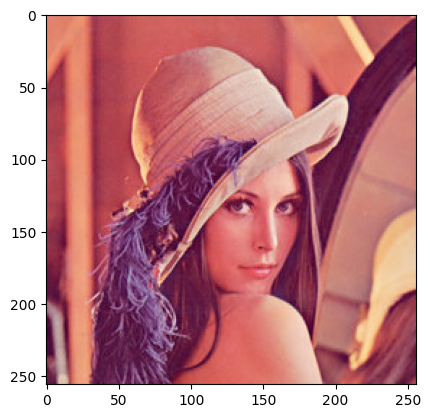

In [20]:
# Convertir BGR en RGB
RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(RGB_img, cmap='gray')
plt.show()

### TRANSFORMACIONES DE INTENSIDAD

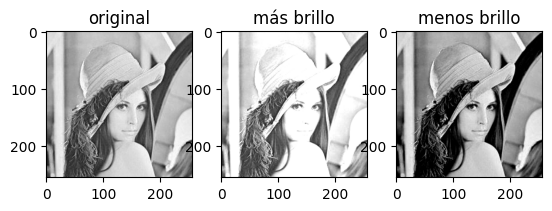

In [21]:
# CAMBIO DE BRILLO
img = cv2.imread('images/Lena_RGB.png')
img = img[:,:,2] # red color

mas_brillo = 50
menos_brillo = -100
mas_brillo_img = cv2.add(img, mas_brillo) # Importante el "cv2.add" en vez de "+"
menos_brillo_img = cv2.add(img, menos_brillo)

fig, ax = plt.subplots(1,3)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(mas_brillo_img, cmap='gray'), ax[1].set_title('más brillo')
ax[2].imshow(menos_brillo_img, cmap='gray'), ax[2].set_title('menos brillo')
plt.show()

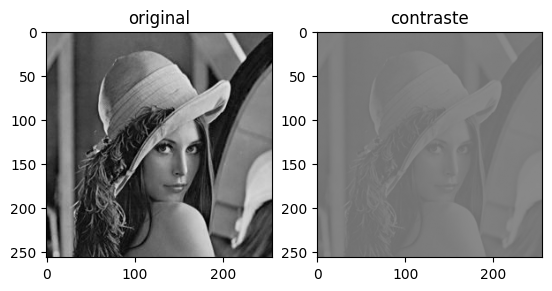

In [22]:
# CAMBIO DE CONTRASTE de acuerdo con el programa GIMP
img = cv2.imread('images/Lena_RGB.png')
img = img[:,:,1] # canal verde

contraste = -100

f = 131*(contraste + 127)/(127*(131-contraste))
alpha_c = f
gamma_c = 127*(1-f)

contrast_img = cv2.addWeighted(img, alpha_c, img, 0, gamma_c)

fig, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray', vmin=0, vmax=255), ax[0].set_title('original')
ax[1].imshow(contrast_img, cmap='gray', vmin=0, vmax=255), ax[1].set_title('contraste')
plt.show()

### CONVERSIONES DEL ESPACIO DE COLOR

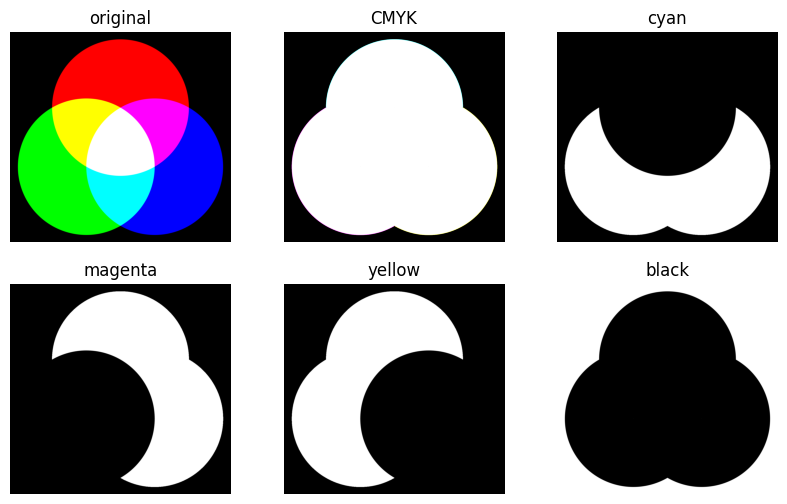

In [23]:
img = io.imread('images/colores.png')
rgb_p = img.astype(float)/255  # Normalizamos a [0,1]

with np.errstate(invalid='ignore', divide='ignore'):
    K = 1 - np.max(rgb_p, axis=2)
    C = (1 - rgb_p[...,0] - K) / (1 - K + 1e-8)
    M = (1 - rgb_p[...,1] - K) / (1 - K + 1e-8)
    Y = (1 - rgb_p[...,2] - K) / (1 - K + 1e-8)

C,M,Y,K = cv2.split((np.dstack((C,M,Y,K))*255).astype('uint8'))

fig, ax = plt.subplots(2,3, figsize=(10,6))
titles = ['original','CMYK','cyan','magenta','yellow','black']
images = [img, np.dstack((C,M,Y,K)), C, M, Y, K]

for i, (im, t) in enumerate(zip(images, titles)):
    ax[i//3, i%3].imshow(im if i<2 else im, cmap=None if i<2 else 'gray')
    ax[i//3, i%3].set_title(t)
    ax[i//3, i%3].axis('off')

plt.show()

In [24]:
# Otras conversiones

img = cv2.imread('images/Lena_RGB.png')

gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # gray-scale

HSV = cv2.cvtColor(img, cv2.COLOR_BGR2HSV) # (H)ue, (S)aturation and (V)alue

Lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab) # (L)uminosidad, a-b colores complementarios

YCrCb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb) # Y-Luma, Cr-Cb crominancia rojo y azul


### TRANSFORMACIONES GEOMÉTRICAS

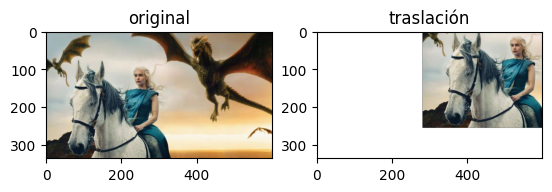

In [25]:
# TRASLACIÓN
img = io.imread('images/GOT.png')
rows, cols, ch = img.shape
 
M = np.float32([[1,0,280],[0,1,-80]]) # Defino la matriz de transformación
new_img = cv2.warpAffine(img,M,(cols,rows)) # Aplico la transformación

figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('traslación')
plt.show()

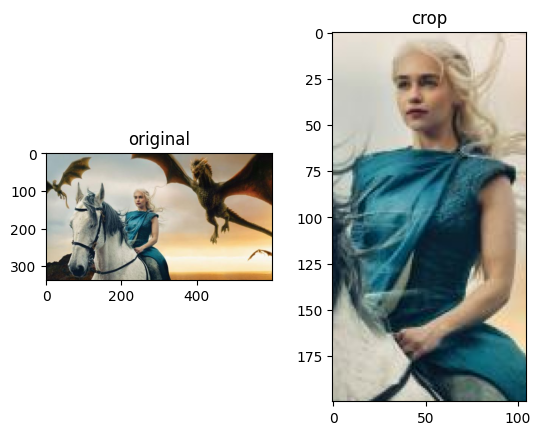

In [26]:
# CROPPING
img = io.imread('images/GOT.png')

new_img = img[90:290, 200:305]

figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('crop')
plt.show()

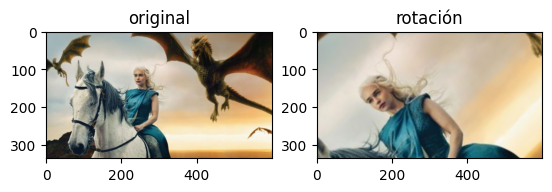

In [27]:
from skimage import io
import cv2
import matplotlib.pyplot as plt

# ROTACIÓN
img = io.imread('images/GOT.png')
rows, cols, ch = img.shape

M = cv2.getRotationMatrix2D((cols/2, rows/2), angle=45, scale=2)  # Matriz de transformación
new_img = cv2.warpAffine(img, M, (cols, rows))  # Aplico la transformación

figs, ax = plt.subplots(1, 2)
ax[0].imshow(img, cmap='gray')
ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray')
ax[1].set_title('rotación')
plt.show()

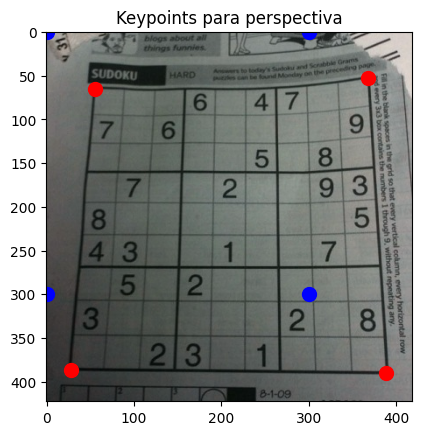

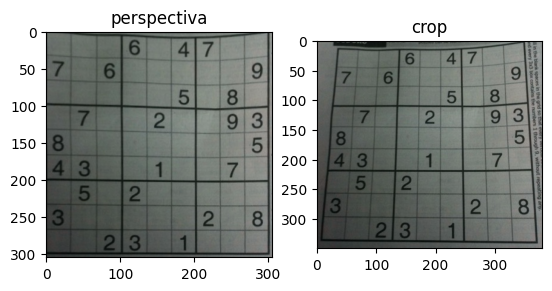

In [28]:
# PERSPECTIVA
img = cv2.imread('images/sudoku.png')
rows, cols, ch = img.shape
 
pts1 = np.float32([[56,65],[368,52],[28,387],[389,390]])
pts2 = np.float32([[0,0],[300,0],[0,300],[300,300]])

plt.imshow(img, cmap='gray')
for i in range(0,4):
    plt.plot(pts1[i,0], pts1[i,1], 'or', markersize=10)
    plt.plot(pts2[i,0], pts2[i,1], 'ob', markersize=10)
plt.title('Keypoints para perspectiva')
plt.show()
 
M = cv2.getPerspectiveTransform(pts1,pts2) # Defino la matriz de transformación
pers = cv2.warpPerspective(img,M,(305,305)) # Aplico la transformación
crop =  img[50:400,20:400]

figs, ax = plt.subplots(1,2)
ax[0].imshow(pers, cmap='gray'), ax[0].set_title('perspectiva')
ax[1].imshow(crop, cmap='gray'), ax[1].set_title('crop')
plt.show()


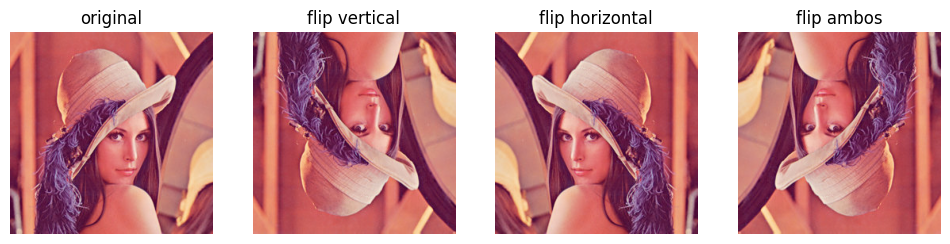

In [16]:
# Leer la imagen "Lena_RGB.png" en formato RGB
img = cv2.imread('images/Lena_RGB.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Voltear la imagen con cv2.flip()
flipVertical = cv2.flip(img, 0)    # flip vertical
flipHorizontal = cv2.flip(img, 1)  # flip horizontal
flipBoth = cv2.flip(img, -1)       # flip vertical + horizontal

# Mostrar resultados
figs, ax = plt.subplots(1, 4, figsize=(12, 4))
ax[0].imshow(img), ax[0].set_title('original')
ax[1].imshow(flipVertical), ax[1].set_title('flip vertical')
ax[2].imshow(flipHorizontal), ax[2].set_title('flip horizontal')
ax[3].imshow(flipBoth), ax[3].set_title('flip ambos')

for a in ax:
    a.axis('off')

plt.show()

**Github:** https://github.com/Maick721/MAQUINAS-E-LEARNING-2-.git

### Instituto Superior Tecnologico Quito

![jupyter](img/itq.png)

**Nombre:** Maiccol Zurita

**Fecha:** 30/03/2026

In [1]:
# Creación aleatoria de datos
import numpy as np
import random
random.seed(42)

In [2]:
nivel_estudios = []
nivel_estudios.extend(['Secundaria']*110)
nivel_estudios.extend(['Bachillerato']*172)
nivel_estudios.extend(['Grado']*145)
nivel_estudios.extend(['Master']*52)
nivel_estudios.extend(['Doctorado']*21)

nivel_estudios = np.random.permutation(nivel_estudios)

In [3]:
print(nivel_estudios)

['Grado' 'Grado' 'Bachillerato' 'Bachillerato' 'Secundaria' 'Secundaria'
 'Bachillerato' 'Secundaria' 'Bachillerato' 'Bachillerato' 'Secundaria'
 'Grado' 'Grado' 'Secundaria' 'Bachillerato' 'Secundaria' 'Grado'
 'Bachillerato' 'Master' 'Doctorado' 'Secundaria' 'Grado' 'Doctorado'
 'Master' 'Grado' 'Secundaria' 'Secundaria' 'Bachillerato' 'Bachillerato'
 'Doctorado' 'Secundaria' 'Bachillerato' 'Grado' 'Bachillerato' 'Grado'
 'Grado' 'Secundaria' 'Secundaria' 'Bachillerato' 'Grado' 'Secundaria'
 'Master' 'Bachillerato' 'Master' 'Master' 'Grado' 'Grado' 'Grado'
 'Secundaria' 'Grado' 'Grado' 'Secundaria' 'Master' 'Master' 'Grado'
 'Secundaria' 'Grado' 'Bachillerato' 'Bachillerato' 'Grado' 'Bachillerato'
 'Doctorado' 'Grado' 'Secundaria' 'Secundaria' 'Grado' 'Secundaria'
 'Bachillerato' 'Bachillerato' 'Bachillerato' 'Grado' 'Grado' 'Secundaria'
 'Secundaria' 'Secundaria' 'Secundaria' 'Grado' 'Grado' 'Secundaria'
 'Grado' 'Bachillerato' 'Bachillerato' 'Grado' 'Master' 'Bachillerato'
 'Grado'

In [4]:
# DIAGRAMA DE BARRAS
import matplotlib.pyplot as plt
import numpy as np
estudios, frecuencia = np.unique(nivel_estudios, return_counts=True)
print(estudios, frecuencia)

['Bachillerato' 'Doctorado' 'Grado' 'Master' 'Secundaria'] [172  21 145  52 110]


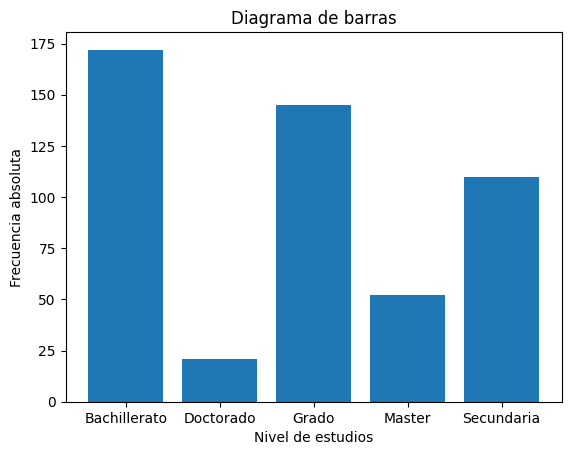

In [5]:
plt.ylabel('Frecuencia absoluta')
plt.xlabel('Nivel de estudios')
plt.title('Diagrama de barras')
plt.bar(estudios, frecuencia) # https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html
plt.show()

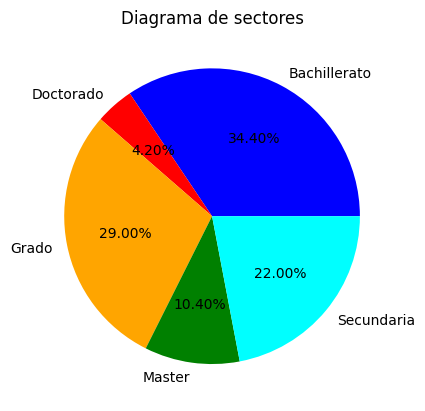

In [6]:
# DIAGRAMA DE SECTORES
colores = {'red', 'blue', 'orange', 'green', 'cyan'}
plt.pie(frecuencia, labels=estudios, colors=colores, autopct='%1.2f%%')
plt.title('Diagrama de sectores')
plt.show()

In [7]:
# Tarea implementar con pandas esta información 

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Creamos un data frame con el nivel de estudio ya con los datos de antes 
df = pd.DataFrame({'Nivel de estudios': nivel_estudios})

# Calcullamos la frecuencia 
frecuencia = df['Nivel de estudios'].value_counts()
#imprimimos el resultado 
print(frecuencia)


Nivel de estudios
Bachillerato    172
Grado           145
Secundaria      110
Master           52
Doctorado        21
Name: count, dtype: int64


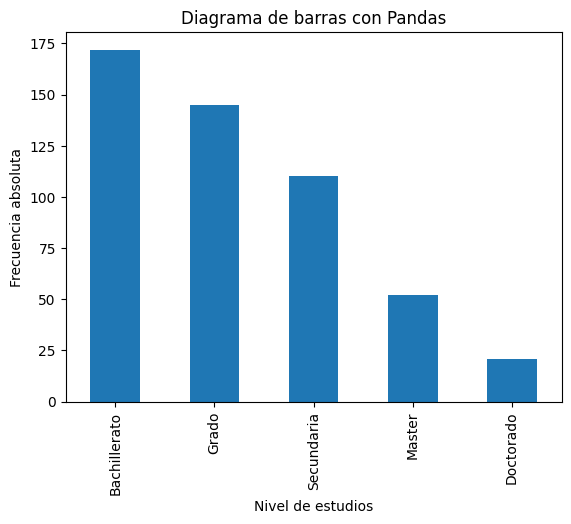

In [15]:
#Creamos el diagrama de barras 
frecuencia.plot(kind='bar')

plt.ylabel('Frecuencia absoluta')
plt.xlabel('Nivel de estudios')
plt.title('Diagrama de barras con Pandas')
plt.show()


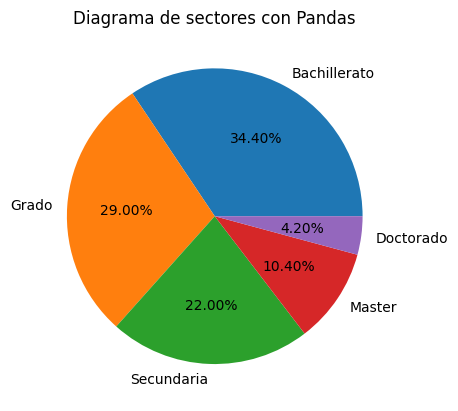

In [16]:
#Creamos el diagrama pastel 
frecuencia.plot(
    kind='pie',
    autopct='%1.2f%%',
    ylabel='',
    title='Diagrama de sectores con Pandas'
)

plt.show()

**Github:** https://github.com/Maick721/MAQUINAS-E-LEARNING-2-.git

### Instituto Superior Tecnologico Quito

![jupyter](img/itq.png)

**Nombre:** Maiccol Zurita

**Fecha:** 30/03/2026

In [1]:
# Creación aleatoria de datos
import numpy as np
X = np.array([0.5, 23, 0.3, 4.5, 0.3, 0.5,
              -28, -50, 60, -100, -10, -11, 13, 19, 1, 9])

In [2]:
# Medidas de tendencia central
from scipy import stats
media = np.mean(X)
mediana = np.median(X)
moda, _ = stats.mode(X)
print('media: ', media)
print('mediana: ', mediana)
print('moda :', moda)

media:  -4.24375
mediana:  0.5
moda : 0.3


In [3]:
# Medidas de posición
import numpy as np
import matplotlib.pyplot as plt

Q1 = np.percentile(X, 25)
Q3 = np.percentile(X, 75)
RIC = Q3 - Q1
lim_inf = Q1 - 1.5*RIC
lim_sup = Q3 + 1.5*RIC

print('RIC :', RIC)
print('limite inferior :', lim_inf)
print('limite superior :', lim_sup)

RIC : 20.25
limite inferior : -40.625
limite superior : 40.375


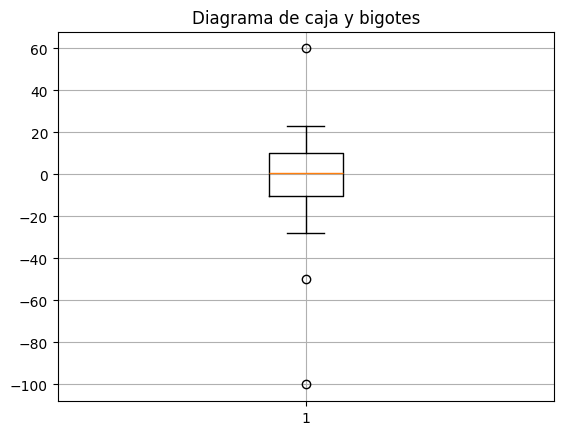

In [4]:
# Dibuja el diagrama de box and whiskers y determina visualmente el número de outliers
plt.boxplot(X)
plt.grid()
plt.title("Diagrama de caja y bigotes")
plt.show()

In [5]:
# Medidas de dispersión
desvest = np.std(X)
print('Desviación típica: ', desvest)
print('Varianza: ', desvest**2)

Desviación típica:  33.521242681880096
Varianza:  1123.6737109375


In [6]:
# Medidas de distribución
asimetria = stats.skew(X)
curtosis = stats.kurtosis(X, fisher=True) # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html
print('Asimetría ', np.round(asimetria, 4))
print('Curtosis ', np.round(curtosis, 4))

if curtosis>0:
    print('Distribución Leptocúrtica')
elif curtosis<0:
    print('Distribución Platicúrtica')
else:
    print('Distribución Mesocúrtica')

Asimetría  -1.1302
Curtosis  2.2858
Distribución Leptocúrtica


In [10]:
from sklearn import datasets
import scipy.stats as stats

iris = datasets.load_iris()
X = iris.data

# Asimetría (longitud del pétalo)
asimetria = stats.skew(X[:, 2])
print("Asimetría:", asimetria)

# Curtosis (ancho del sépalo)
curtosis = stats.kurtosis(X[:, 1])
print("Curtosis:", curtosis)

Asimetría: -0.2721276664567214
Curtosis: 0.18097631752246768


# EJERCICIO EXTRA SOBRE EL DATASET DE IRIS
# Extraer la media y la desviación típica de cada variable en función de la clase y representarlo en un gráfico (plt.errorbar)

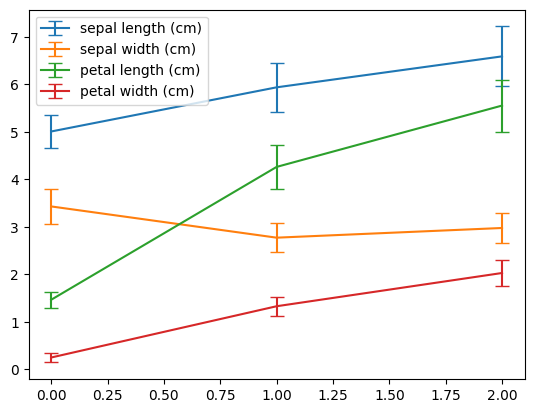

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

iris = datasets.load_iris()
X, y = iris.data, iris.target

# Calcular media y desviación por clase 
means = [X[y == i].mean(axis=0) for i in range(3)]
stds  = [X[y == i].std(axis=0)  for i in range(3)]

# Graficar
for i in range(4):
    plt.errorbar(range(3), [m[i] for m in means],
                 yerr=[s[i] for s in stds],
                 label=iris.feature_names[i],
                 capsize=5)

plt.legend()
plt.show()

**Github:** https://github.com/Maick721/MAQUINAS-E-LEARNING-2-.git